##Анализ продуктивности сотрудников

In [ ]:
import pandas as pd

# Загружаем файл с компьютера
from google.colab import files
uploaded = files.upload()   # появится кнопка для выбора файла

# Чтение CSV
df = pd.read_csv("Employee_Productivity.csv")

# Просмотр первых строк
df.head()


Saving Employee_Productivity.csv to Employee_Productivity.csv


,Employee_ID,Department,Experience_Years,Technical_Skill_Score,Communication_Score,Training_Hours,Projects_Completed,Avg_Weekly_Work_Hours,Productivity_Score,Salary_USD
0,E001,Data Science,5.0,92.0,85.0,120.0,18.0,42.0,88.0,85000.0
1,E002,Machine Learning,3.0,89.0,78.0,90.0,15.0,45.0,82.0,78000.0
2,E003,Data Analysis,2.0,75.0,80.0,70.0,10.0,40.0,76.0,62000.0
3,E004,Data Engineering,6.0,95.0,88.0,150.0,22.0,44.0,91.0,92000.0
4,E005,BI & Analytics,4.0,82.0,90.0,110.0,16.0,41.0,85.0,78000.0


In [ ]:
df.columns          # список названий колонок

Index(['Employee_ID', 'Department', 'Experience_Years',
       'Technical_Skill_Score', 'Communication_Score', 'Training_Hours',
       'Projects_Completed', 'Avg_Weekly_Work_Hours', 'Productivity_Score',
       'Salary_USD'],
      dtype='object')

`Employee ID` - Идентификатор сотрудника

`Department` - Отделение

`Experience Years` - Опыт лет

`Technical Skill Score` - оценка технических навыков

`Communication Score` - оценка коммуникации

`Training Hours` - часы обучения

`Projects Completed` - завершенные проекты

`Avg Weekly Work Hours` -  еженедельные рабочие часы AVG

`Productivity Score` - оценка производительности

`Salary USD` - зарплата долларов США

In [ ]:
df.shape            # количество строк и столбцов


(11, 10)

In [ ]:
df.info()           # информация о столбцах и типах данных

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Employee_ID            11 non-null     object 
 1   Department             10 non-null     object 
 2   Experience_Years       10 non-null     float64
 3   Technical_Skill_Score  10 non-null     float64
 4   Communication_Score    10 non-null     float64
 5   Training_Hours         10 non-null     float64
 6   Projects_Completed     10 non-null     float64
 7   Avg_Weekly_Work_Hours  10 non-null     float64
 8   Productivity_Score     10 non-null     float64
 9   Salary_USD             10 non-null     float64
dtypes: float64(8), object(2)
memory usage: 1012.0+ bytes


Во всех числовых колонках и в Department есть по 1 пропущенному значению (всего 10 non-null из 11).
Нужно будет обработать пропуски: например, заполнить медианой или удалить строку.

In [ ]:
# Удаляем строки, где есть хотя бы один NaN
df_clean = df.dropna()

# Проверим результат
print(df_clean.info())
print(df_clean.head())

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 0 to 9
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Employee_ID            10 non-null     object 
 1   Department             10 non-null     object 
 2   Experience_Years       10 non-null     float64
 3   Technical_Skill_Score  10 non-null     float64
 4   Communication_Score    10 non-null     float64
 5   Training_Hours         10 non-null     float64
 6   Projects_Completed     10 non-null     float64
 7   Avg_Weekly_Work_Hours  10 non-null     float64
 8   Productivity_Score     10 non-null     float64
 9   Salary_USD             10 non-null     float64
dtypes: float64(8), object(2)
memory usage: 880.0+ bytes
None
  Employee_ID        Department  Experience_Years  Technical_Skill_Score  \
0        E001      Data Science               5.0                   92.0   
1        E002  Machine Learning               3.0                

In [ ]:
df.describe()       # основные статистики (среднее, медиана и т.д.)

,Experience_Years,Technical_Skill_Score,Communication_Score,Training_Hours,Projects_Completed,Avg_Weekly_Work_Hours,Productivity_Score,Salary_USD
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,4.000000,86.100000,83.700000,110.500000,16.400000,42.100000,84.100000,79400.000000
std,1.825742,8.412293,5.558777,32.011283,5.103376,2.469818,7.030884,12997.435645
min,1.000000,70.000000,75.000000,60.000000,8.000000,38.000000,70.000000,55000.000000
25%,3.000000,82.750000,79.250000,92.500000,14.250000,40.250000,81.250000,76500.000000
50%,4.000000,88.000000,84.500000,112.500000,16.500000,42.000000,86.000000,80500.000000
75%,5.000000,91.500000,87.500000,127.500000,18.750000,43.750000,88.000000,86500.000000
max,7.000000,96.000000,92.000000,160.000000,25.000000,46.000000,93.000000,98000.000000


Большинство сотрудников имеют опыт 3–5 лет (см. 25–75% квантили).Выборка скорее состоит из специалистов среднего уровня.
Видно, что сотрудники технически хорошо подготовлены.
Почти все имеют хорошие soft skills.
Команда сбалансирована по коммуникации, но есть те, кто немного слабее (min = 75).
Большой разброс (std ≈ 32) → некоторые учатся почти в 2 раза больше, чем другие.
Средняя зарплата: 79 400 $.
Диапазон: от 55 000 до 98 000 $.
Разброс довольно высокий (std ≈ 13 000 $).

In [ ]:
!pip install skimpy

from skimpy import skim

skim(df)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.1/106.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: jupyter-client
    Found existing installation: jupyter_client 7.4.9
    Uninstalling jupyter_client-7.4.9:
      Successfully uninstalled jupyter_client-7.4.9
  Attempting uninstall: ipykernel
    Found existing installation: ipykernel 6.17.1
    Uninstalling ipykernel-6.17.1:
      Successfully uninstalled ipykernel-6.17.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are inst

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 11     │ │ float64     │ 8     │                                                          │
│ │ Number of columns │ 10     │ │ string      │ 2     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column            ┃ NA ┃ NA %             ┃ mean  ┃ sd    ┃ p0    ┃ p25   ┃ p50   ┃ p75   ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ Experience_Years  │  1 │ 9.09090909090909 │     4 │ 1.826 │     1 │     3 │     4 │     5 │     7 │ ▄▄████ │  │
│ │                   │    │                2 │       │       │       │       │       │       │       │        │  │
│ │ Technical_Skill_S │  1 │ 9.09090909090909 │  86.1 │ 8.412 │    70 │ 82.75 │    88 │  91.5 │    96 │ ▃▃▃▅▅█ │  │
│ │ core              │    │                2 │       │       │       │       │       │       │       │        │  │
│ │ Communication_Sco │  1 │ 9.09090909090909 │  83.7 │ 5.559 │    75 │ 79.25 │  84.5 │  87.5 │    92 │ ▃█ █▃▅ │  │
│ │ re                │    │                2 │       │       │       │       │       │       │       │        │  │
│ │ Training_Hours    │  1 │ 9.09090909090909 │ 110.5 │ 32.01 │    60 │  92.5 │ 112.5 │ 127.5 │   160 │ ▅▃▃█▃▅ │  │
│ │                   │    │                2 │       │       │       │       │       │       │       │        │  │
│ │ Projects_Complete │  1 │ 9.09090909090909 │  16.4 │ 5.103 │     8 │ 14.25 │  16.5 │ 18.75 │    25 │ ▅ ██▃▃ │  │
│ │ d                 │    │                2 │       │       │       │       │       │       │       │        │  │
│ │ Avg_Weekly_Work_H │  1 │ 9.09090909090909 │  42.1 │  2.47 │    38 │ 40.25 │    42 │ 43.75 │    46 │ ▃▅▃█▃▅ │  │
│ │ ours              │    │                2 │       │       │       │       │       │       │       │        │  │
│ │ Productivity_Scor │  1 │ 9.09090909090909 │  84.1 │ 7.031 │    70 │ 81.25 │    86 │    88 │    93 │ ▃▃▃▅█▅ │  │
│ │ e                 │    │                2 │       │       │       │       │       │       │       │        │  │
│ │ Salary_USD        │  1 │ 9.09090909090909 │ 79400 │ 13000 │ 55000 │ 76500 │ 80500 │ 86500 │ 98000 │ ▅ ▃█▅▅ │  │
│ │                   │    │                2 │       │       │       │       │       │       │       │        │  │
│ └───────────────────┴────┴──────────────────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓  │
│ ┃           ┃    ┃           ┃          ┃           ┃          ┃           ┃ chars    ┃ words per ┃ total    ┃  │
│ ┃ column    ┃ NA ┃ NA %      ┃ shortest ┃ longest   ┃ min      ┃ max       ┃ per row  ┃ row       ┃ words    ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩  │
│ │ Employee_ │  0 │         0 │ E001     │ Язык этой │ 

*Есть смысл проверить гипотезы:
Больше проектов → выше продуктивность;
Больше опыта → выше зарплата;
Больше часов обучения → выше продуктивность.*

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd

In [10]:
mean_vals = df.mean(numeric_only=True)
median_vals = df.median(numeric_only=True)
std_vals = df.std(numeric_only=True)

print("Средние значения:\n", mean_vals)
print("Медианы:\n", median_vals)
print("Стандартные отклонения:\n", std_vals)


Средние значения:
 Experience_Years             4.0
Technical_Skill_Score       86.1
Communication_Score         83.7
Training_Hours             110.5
Projects_Completed          16.4
Avg_Weekly_Work_Hours       42.1
Productivity_Score          84.1
Salary_USD               79400.0
dtype: float64
Медианы:
 Experience_Years             4.0
Technical_Skill_Score       88.0
Communication_Score         84.5
Training_Hours             112.5
Projects_Completed          16.5
Avg_Weekly_Work_Hours       42.0
Productivity_Score          86.0
Salary_USD               80500.0
dtype: float64
Стандартные отклонения:
 Experience_Years             1.825742
Technical_Skill_Score        8.412293
Communication_Score          5.558777
Training_Hours              32.011283
Projects_Completed           5.103376
Avg_Weekly_Work_Hours        2.469818
Productivity_Score           7.030884
Salary_USD               12997.435645
dtype: float64


**ГИСТОГРАММА ДЛЯ КАЖДОГО ПРИЗНАКА**

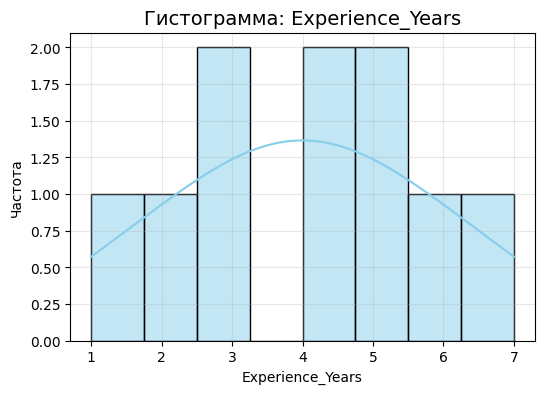

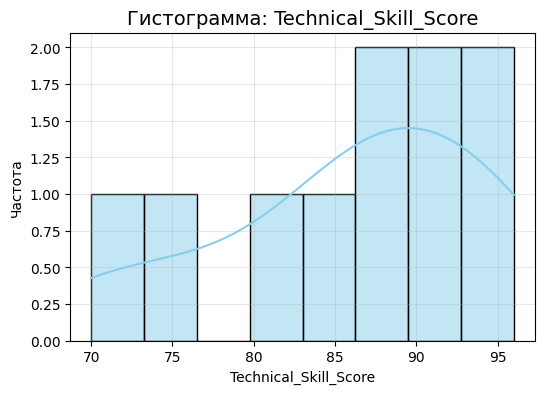

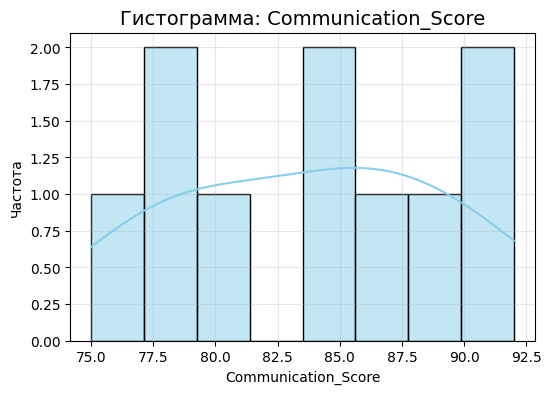

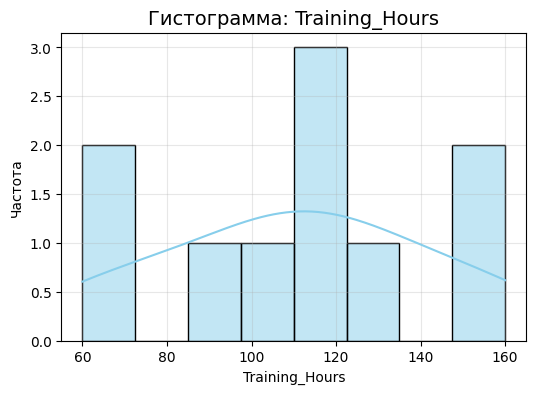

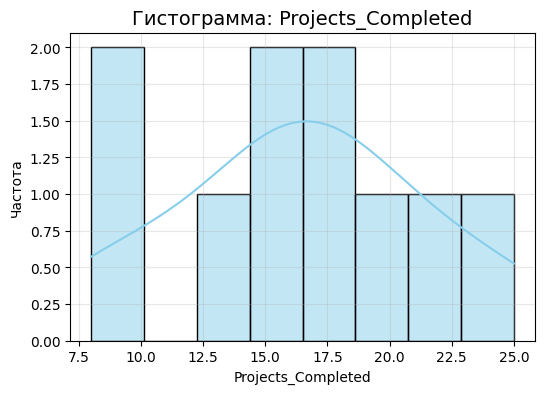

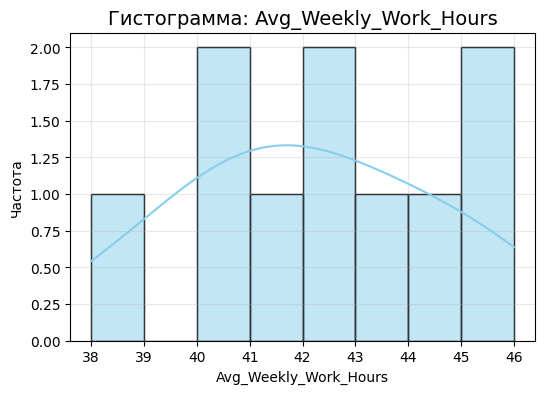

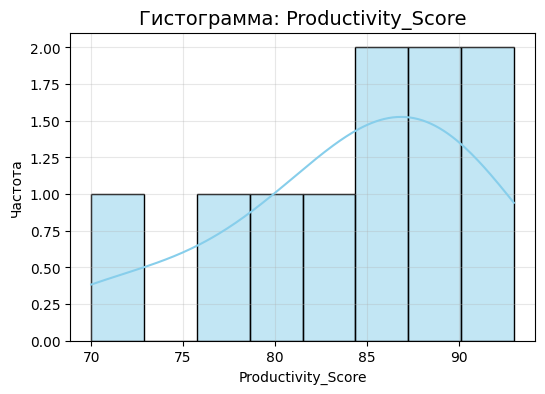

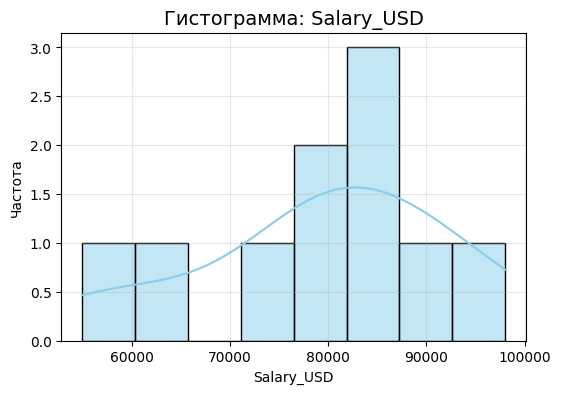

In [17]:
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_clean[col], kde=True, bins=8, color='skyblue')
    plt.title(f'Гистограмма: {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Частота')
    plt.grid(alpha=0.3)
    plt.show()

Гистограмма для отдельного признака

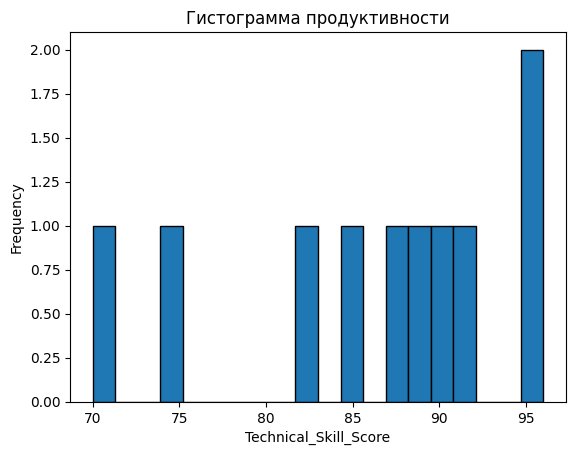

In [18]:

plt.hist(df['Technical_Skill_Score'], bins=20, edgecolor='black')
plt.xlabel('Technical_Skill_Score')
plt.ylabel('Frequency')
plt.title('Гистограмма продуктивности')
plt.show()


**ДИАГРАММА РАЗМАХА ДЛЯ КАЖДОГО ПРИЗНАКА**

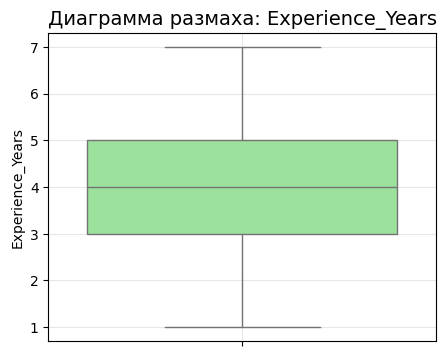

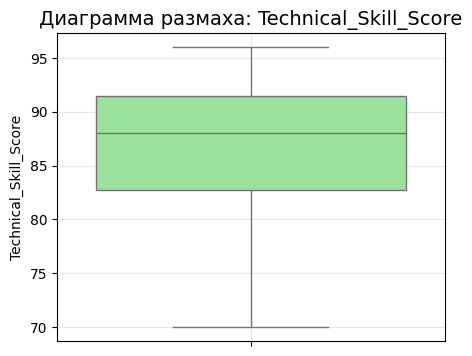

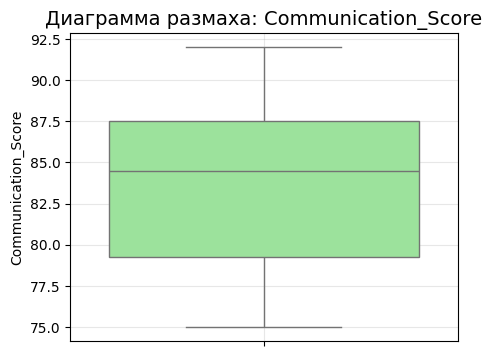

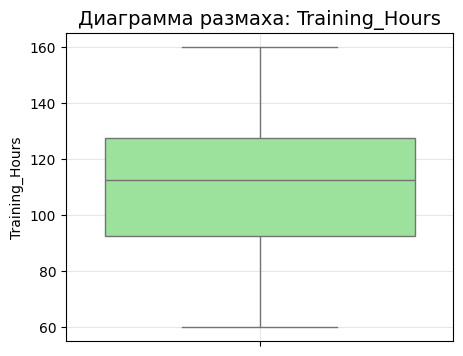

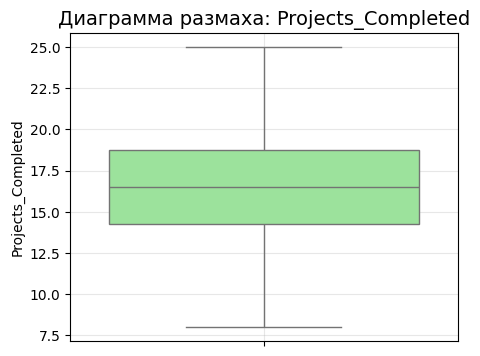

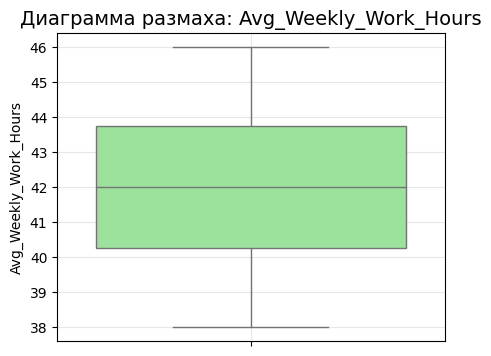

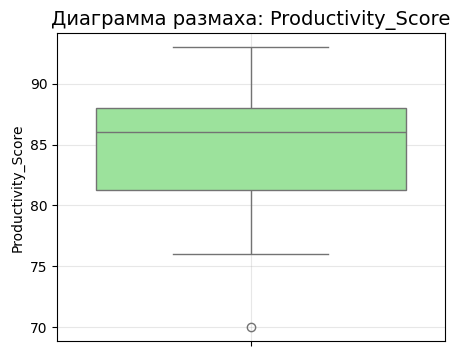

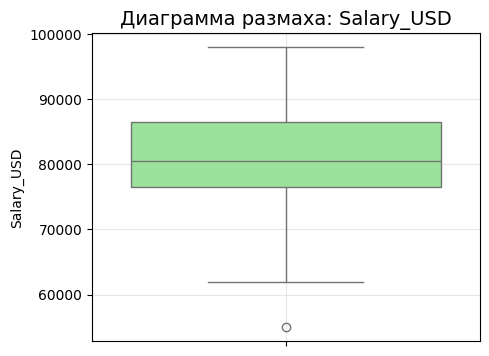

In [19]:
for col in numeric_cols:
    plt.figure(figsize=(5, 4))
    sns.boxplot(y=df_clean[col], color='lightgreen')
    plt.title(f'Диаграмма размаха: {col}', fontsize=14)
    plt.ylabel(col)
    plt.grid(alpha=0.3)
    plt.show()

Диаграма размаха для конкретного

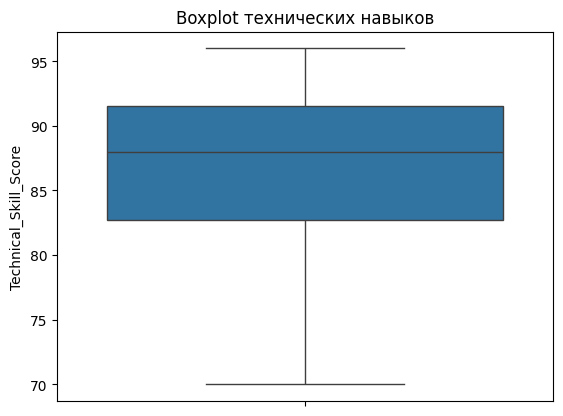

In [20]:
import seaborn as sns

sns.boxplot(y=df['Technical_Skill_Score'])
plt.title('Boxplot технических навыков')
plt.show()


**Точечная диаграмма зависимости опыта и продуктивности**

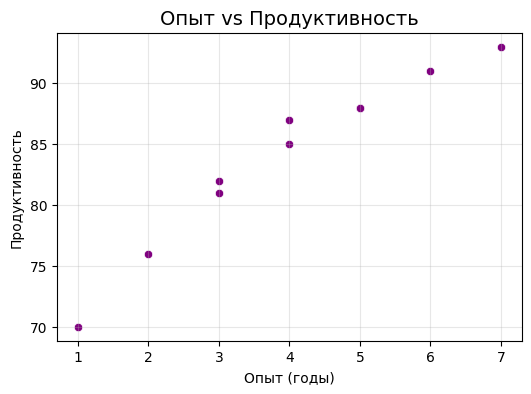

In [21]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_clean, x='Experience_Years', y='Productivity_Score', color='purple')
plt.title('Опыт vs Продуктивность', fontsize=14)
plt.xlabel('Опыт (годы)')
plt.ylabel('Продуктивность')
plt.grid(alpha=0.3)
plt.show()


На графике видно: при росте опыта наблюдается и продуктивность работников, например, при первом годе работы значение продуктивности = 70, а при 4х годах уже 85. Так, мы видим линейную зависимость между показателями.

**Точечная диаграмма зависимости обучения и продуктивности**

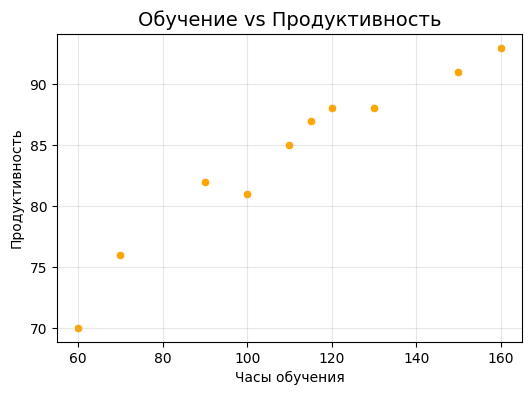

In [22]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_clean, x='Training_Hours', y='Productivity_Score', color='orange')
plt.title('Обучение vs Продуктивность', fontsize=14)
plt.xlabel('Часы обучения')
plt.ylabel('Продуктивность')
plt.grid(alpha=0.3)
plt.show()

Также видно, что часы обучения влияют на пробуктивность сотрудников

**Точечная диаграмма зависимости проектов и зарплаты**

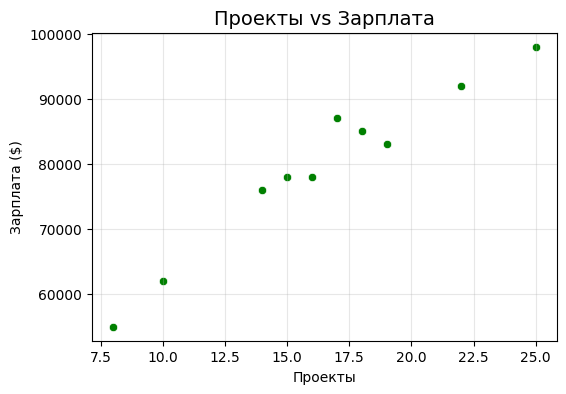

In [23]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_clean, x='Projects_Completed', y='Salary_USD', color='green')
plt.title('Проекты vs Зарплата', fontsize=14)
plt.xlabel('Проекты')
plt.ylabel('Зарплата ($)')
plt.grid(alpha=0.3)
plt.show()

Конечно, зарплата сотрудников связанаа с их количеством выполненых проектов, а количество выполненых проектов с продуктивность, ктороя зависит от опыта работы и часов обучения)

**Корреляционная матрица**

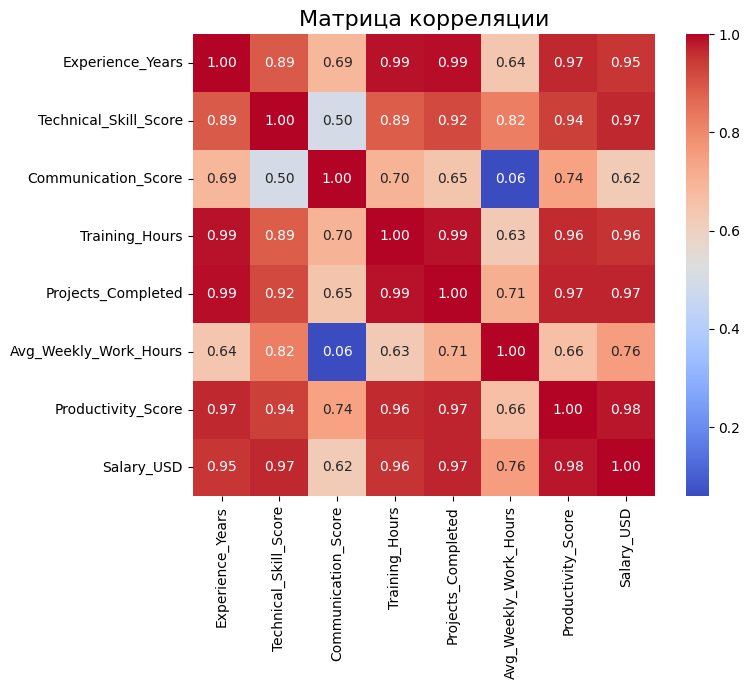

In [25]:
corr_matrix = df_clean.corr(numeric_only=True)

# Тепловая карта
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Матрица корреляции', fontsize=16)
plt.show()

 Мы видим в данных сильную мультиколлинеарность между данными.

 Возьмем результативным признаком *Оценку производительности*: сильная корреляция с:
- Experience_Years — 0.97
- Training_Hours — 0.96
- Projects_Completed — 0.97
- Technical_Skill_Score — 0.94

 Возьмем результативным признаком *Зарплату*: сильная корреляция с:
- Technical_Skill_Score — 0.97
- Experience_Years — 0.95
- Training_Hours — 0.96
- Projects_Completed — 0.97
- Productivity_Score — 0.98

 Видно, что признаки взаимозаменяемы, их нельзя брать вместе в регрессию — модель станет нестабильной и коэффициенты потеряют смысл.
Experience_Years ↔ Training_Hours — 0.99
Experience_Years ↔ Projects_Completed — 0.99
Training_Hours ↔ Projects_Completed — 0.99
Experience_Years ↔ Technical_Skill_Score — 0.89
Technical_Skill_Score ↔ Projects_Completed — 0.92

Из них оставляем Experience_Years, Technical_Skill_Score, Avg_Weekly_Work_Hours, Communication_Score.



Допустим мы будем прогнозировать продуктивность сотрудников


In [26]:
features = ['Experience_Years',
            'Technical_Skill_Score',
            'Communication_Score',
            'Avg_Weekly_Work_Hours']
target = 'Productivity_Score'


In [32]:
import statsmodels.api as sm

# Отбор признаков
X = df_clean[['Experience_Years',
              'Technical_Skill_Score',
              'Communication_Score',
              'Avg_Weekly_Work_Hours']]
y = df_clean['Productivity_Score']

# Добавляем константу (intercept)
X_const = sm.add_constant(X)

# Строим модель OLS (метод наименьших квадратов)
model = sm.OLS(y, X_const).fit()

# Выводим результаты
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:     Productivity_Score   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                     279.9
Date:                Wed, 01 Oct 2025   Prob (F-statistic):           4.60e-06
Time:                        16:06:06   Log-Likelihood:                -6.0863
No. Observations:                  10   AIC:                             22.17
Df Residuals:                       5   BIC:                             23.69
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     6.05

Что мы видим в проверке значимости:
- R² = 0.996 → модель объясняет 99,6% вариации продуктивности
- отдельные факторы:
Опыт, технические и коммуникационные навыки — действительно влияют на продуктивность.

Среднее количество рабочих часов не даёт статистически значимого вклада → можно исключить из модели.

Если увеличить Experience_Years на 1 год → продуктивность ↑ в среднем на 1.32 пункта.

Если повысить Technical_Skill_Score на 1 пункт → продуктивность ↑ на 0.33 пункта.

Если улучшить Communication_Score на 1 пункт → продуктивность ↑ на 0.38 пункта.

Рабочие часы не дают достоверного эффекта (коэф. ≈ 0.29, но не значим).

- модель хорошо объясняет зависимость Productivity_Score

ПЕРЕСОБИРАЕМ МОДЕЛЬ

In [34]:
X2 = df_clean[['Experience_Years',
               'Technical_Skill_Score',
               'Communication_Score']]
X2_const = sm.add_constant(X2)
model2 = sm.OLS(y, X2_const).fit()
print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:     Productivity_Score   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     328.9
Date:                Wed, 01 Oct 2025   Prob (F-statistic):           4.82e-07
Time:                        16:15:38   Log-Likelihood:                -7.6230
No. Observations:                  10   AIC:                             23.25
Df Residuals:                       6   BIC:                             24.46
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    16.85

Наше уравнение модели:

Productivity_Score=16.85+1.39×Experience_Years+0.41×Technical_Skill_Score+0.32×Communication_Score


In [36]:
import pandas as pd
import statsmodels.api as sm

# --- Пример новых сотрудников ---
new_employees = pd.DataFrame({
    'Experience_Years': [2, 5, 7],
    'Technical_Skill_Score': [80, 90, 95],
    'Communication_Score': [78, 85, 88]
})

# Добавляем константу (обязательно для OLS)
new_employees_const = sm.add_constant(new_employees)

# Прогноз с использованием обученной модели
predictions = model2.predict(new_employees_const)

# Вывод
for i, pred in enumerate(predictions):
    print(f'Сотрудник {i+1}: прогнозная продуктивность = {pred:.2f}')



Сотрудник 1: прогнозная продуктивность = 77.02
Сотрудник 2: прогнозная продуктивность = 87.50
Сотрудник 3: прогнозная продуктивность = 93.28


ПРОГНОЗ ЗП

In [37]:
import statsmodels.api as sm

# Выбираем признаки
X_salary = df_clean[['Experience_Years',
                     'Technical_Skill_Score',
                     'Projects_Completed',
                     'Productivity_Score']]
y_salary = df_clean['Salary_USD']

# Добавляем константу
X_salary_const = sm.add_constant(X_salary)

# Строим модель
model_salary = sm.OLS(y_salary, X_salary_const).fit()

# Результаты
print(model_salary.summary())


                            OLS Regression Results                            
Dep. Variable:             Salary_USD   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     150.5
Date:                Wed, 01 Oct 2025   Prob (F-statistic):           2.14e-05
Time:                        16:26:04   Log-Likelihood:                -84.391
No. Observations:                  10   AIC:                             178.8
Df Residuals:                       5   BIC:                             180.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                 -5.592e+

In [39]:
import statsmodels.api as sm

# Выбираем признаки
X_salary = df_clean[['Technical_Skill_Score',
                     'Productivity_Score']]
y_salary = df_clean['Salary_USD']

# Добавляем константу
X_salary_const = sm.add_constant(X_salary)

# Строим модель
model_salary = sm.OLS(y_salary, X_salary_const).fit()

# Результаты
print(model_salary.summary())


                            OLS Regression Results                            
Dep. Variable:             Salary_USD   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     224.9
Date:                Wed, 01 Oct 2025   Prob (F-statistic):           4.46e-07
Time:                        16:27:00   Log-Likelihood:                -87.496
No. Observations:                  10   AIC:                             181.0
Df Residuals:                       7   BIC:                             181.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                 -6.825e+

In [40]:
new_employees = pd.DataFrame({
    'Technical_Skill_Score': [80, 90],
    'Productivity_Score': [82, 90]
})

# Добавляем константу
new_employees_const = sm.add_constant(new_employees)

# Прогноз
salary_pred = model_salary.predict(new_employees_const)

# Вывод
for i, pred in enumerate(salary_pred):
    print(f'Сотрудник {i+1}: прогнозная зарплата = ${pred:,.2f}')


Сотрудник 1: прогнозная зарплата = $73,244.90
Сотрудник 2: прогнозная зарплата = $88,421.02
